### Prerequsite - Upgrade Scikit Learn
The current workspace has scikit-learn v0.19.1 installed. However, you can upgrade scikit-learn to 0.24.x. and use this [OneHotEncoder](https://scikit-learn.org/0.21/modules/generated/sklearn.preprocessing.OneHotEncoder.html) library. 


In [1]:
import sklearn
print('The scikit-learn version is {}.'.format(sklearn.__version__))

The scikit-learn version is 0.24.2.


In [2]:
import os
os.environ['PATH'] = f"{os.environ['PATH']}:/root/.local/bin"

In [3]:
import sklearn
print('The scikit-learn version is {}.'.format(sklearn.__version__))

The scikit-learn version is 0.24.2.


In [4]:
# Now you can import and use OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
# your code goes here

In [5]:
# Similarly, should you need any other package, they can install it as:
!python -m pip install 'tensorflow-tensorboard<0.2.0,>=0.1.0'

# Project: Identify Customer Segments

In this project, you will apply unsupervised learning techniques to identify segments of the population that form the core customer base for a mail-order sales company in Germany. These segments can then be used to direct marketing campaigns towards audiences that will have the highest expected rate of returns. The data that you will use has been provided by our partners at Bertelsmann Arvato Analytics, and represents a real-life data science task.

This notebook will help you complete this task by providing a framework within which you will perform your analysis steps. In each step of the project, you will see some text describing the subtask that you will perform, followed by one or more code cells for you to complete your work. **Feel free to add additional code and markdown cells as you go along so that you can explore everything in precise chunks.** The code cells provided in the base template will outline only the major tasks, and will usually not be enough to cover all of the minor tasks that comprise it.

It should be noted that while there will be precise guidelines on how you should handle certain tasks in the project, there will also be places where an exact specification is not provided. **There will be times in the project where you will need to make and justify your own decisions on how to treat the data.** These are places where there may not be only one way to handle the data. In real-life tasks, there may be many valid ways to approach an analysis task. One of the most important things you can do is clearly document your approach so that other scientists can understand the decisions you've made.

At the end of most sections, there will be a Markdown cell labeled **Discussion**. In these cells, you will report your findings for the completed section, as well as document the decisions that you made in your approach to each subtask. **Your project will be evaluated not just on the code used to complete the tasks outlined, but also your communication about your observations and conclusions at each stage.**

In [6]:
# import libraries here; add more as necessary
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# magic word for producing visualizations in notebook
%matplotlib inline

'''
Import note: The classroom currently uses sklearn version 0.19.
If you need to use an imputer, it is available in sklearn.preprocessing.Imputer,
instead of sklearn.impute as in newer versions of sklearn.
'''
pd.options.display.max_rows = None
pd.options.display.max_columns = None

### Step 0: Load the Data

There are four files associated with this project (not including this one):

- `Udacity_AZDIAS_Subset.csv`: Demographics data for the general population of Germany; 891211 persons (rows) x 85 features (columns).
- `Udacity_CUSTOMERS_Subset.csv`: Demographics data for customers of a mail-order company; 191652 persons (rows) x 85 features (columns).
- `Data_Dictionary.md`: Detailed information file about the features in the provided datasets.
- `AZDIAS_Feature_Summary.csv`: Summary of feature attributes for demographics data; 85 features (rows) x 4 columns

Each row of the demographics files represents a single person, but also includes information outside of individuals, including information about their household, building, and neighborhood. You will use this information to cluster the general population into groups with similar demographic properties. Then, you will see how the people in the customers dataset fit into those created clusters. The hope here is that certain clusters are over-represented in the customers data, as compared to the general population; those over-represented clusters will be assumed to be part of the core userbase. This information can then be used for further applications, such as targeting for a marketing campaign.

To start off with, load in the demographics data for the general population into a pandas DataFrame, and do the same for the feature attributes summary. Note for all of the `.csv` data files in this project: they're semicolon (`;`) delimited, so you'll need an additional argument in your [`read_csv()`](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.read_csv.html) call to read in the data properly. Also, considering the size of the main dataset, it may take some time for it to load completely.

Once the dataset is loaded, it's recommended that you take a little bit of time just browsing the general structure of the dataset and feature summary file. You'll be getting deep into the innards of the cleaning in the first major step of the project, so gaining some general familiarity can help you get your bearings.

In [7]:
# Load in the general demographics data.
azdias = pd.read_csv('Udacity_AZDIAS_Subset.csv', sep=';')
# Load in the feature summary file.
feat_info = pd.read_csv('AZDIAS_Feature_Summary.csv', sep=';')

In [8]:
# Check the structure of the data after it's loaded (e.g. print the number of
# rows and columns, print the first few rows).
print("AZDIAS shape:", azdias.shape)
print("Feature Summary shape:", feat_info.shape)


AZDIAS shape: (891221, 85)
Feature Summary shape: (85, 4)


In [9]:
display(azdias.head())

,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GEBURTSJAHR,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,LP_FAMILIE_FEIN,LP_FAMILIE_GROB,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,PRAEGENDE_JUGENDJAHRE,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,SOHO_KZ,TITEL_KZ,VERS_TYP,ZABEOTYP,ALTER_HH,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,KK_KUNDENTYP,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,OST_WEST_KZ,WOHNLAGE,CAMEO_DEUG_2015,CAMEO_DEU_2015,CAMEO_INTL_2015,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_BAUMAX,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,-1,2,1,2.0,3,4,3,5,5,3,4,0,10.0,0,-1,15.0,4.0,2.0,2.0,1.0,1.0,0,0,5.0,2,6,7,5,1,5,3,3,4,7,6,6,5,3,-1,NaN,NaN,-1,3,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-1,1,2,5.0,1,5,2,5,4,5,1,1996,10.0,0,3,21.0,6.0,5.0,3.0,2.0,1.0,1,14,1.0,5,4,4,3,1,2,2,3,6,4,7,4,7,6,3,1.0,0.0,2,5,0.0,2.0,0.0,6.0,NaN,3.0,9.0,11.0,0.0,8.0,1.0,1992.0,W,4.0,8,8A,51,0.0,0.0,0.0,2.0,5.0,1.0,6.0,3.0,8.0,3.0,2.0,1.0,3.0,3.0,963.0,2.0,3.0,2.0,1.0,1.0,5.0,4.0,3.0,5.0,4.0
2,-1,3,2,3.0,1,4,1,2,3,5,1,1979,10.0,1,3,3.0,1.0,1.0,1.0,3.0,2.0,1,15,3.0,4,1,3,3,4,4,6,3,4,7,7,7,3,3,2,0.0,0.0,1,5,17.0,1.0,0.0,4.0,NaN,3.0,9.0,10.0,0.0,1.0,5.0,1992.0,W,2.0,4,4C,24,1.0,3.0,1.0,0.0,0.0,3.0,2.0,4.0,4.0,4.0,2.0,3.0,2.0,2.0,712.0,3.0,3.0,1.0,0.0,1.0,4.0,4.0,3.0,5.0,2.0
3,2,4,2,2.0,4,2,5,2,1,2,6,1957,1.0,0,2,0.0,0.0,0.0,0.0,9.0,4.0,1,8,2.0,5,1,2,1,4,4,7,4,3,4,4,5,4,4,1,0.0,0.0,1,3,13.0,0.0,0.0,1.0,NaN,NaN,9.0,1.0,0.0,1.0,4.0,1997.0,W,7.0,2,2A,12,4.0,1.0,0.0,0.0,1.0,4.0,4.0,2.0,6.0,4.0,0.0,4.0,1.0,0.0,596.0,2.0,2.0,2.0,0.0,1.0,3.0,4.0,2.0,3.0,3.0
4,-1,3,1,5.0,4,3,4,1,3,2,5,1963,5.0,0,3,32.0,10.0,10.0,5.0,3.0,2.0,1,8,5.0,6,4,4,2,7,4,4,6,2,3,2,2,4,2,2,0.0,0.0,2,4,20.0,4.0,0.0,5.0,1.0,2.0,9.0,3.0,0.0,1.0,4.0,1992.0,W,3.0,6,6B,43,1.0,4.0,1.0,0.0,0.0,3.0,2.0,5.0,1.0,5.0,3.0,3.0,5.0,5.0,435.0,2.0,4.0,2.0,1.0,2.0,3.0,3.0,4.0,6.0,5.0


In [10]:
print("\n--- Feature Summary First Few Rows ---")
display(feat_info.head())


--- Feature Summary First Few Rows ---


,attribute,information_level,type,missing_or_unknown
0,AGER_TYP,person,categorical,"[-1,0]"
1,ALTERSKATEGORIE_GROB,person,ordinal,"[-1,0,9]"
2,ANREDE_KZ,person,categorical,"[-1,0]"
3,CJT_GESAMTTYP,person,categorical,[0]
4,FINANZ_MINIMALIST,person,ordinal,[-1]


In [11]:
print("\n--- AZDIAS Info ---")
print(azdias.dtypes.value_counts())
print("\nMissing values in AZDIAS:", azdias.isnull().sum().sum())


--- AZDIAS Info ---
float64    49
int64      32
object      4
dtype: int64

Missing values in AZDIAS: 4896838


> **Tip**: Add additional cells to keep everything in reasonably-sized chunks! Keyboard shortcut `esc --> a` (press escape to enter command mode, then press the 'A' key) adds a new cell before the active cell, and `esc --> b` adds a new cell after the active cell. If you need to convert an active cell to a markdown cell, use `esc --> m` and to convert to a code cell, use `esc --> y`. 

## Step 1: Preprocessing

### Step 1.1: Assess Missing Data

The feature summary file contains a summary of properties for each demographics data column. You will use this file to help you make cleaning decisions during this stage of the project. First of all, you should assess the demographics data in terms of missing data. Pay attention to the following points as you perform your analysis, and take notes on what you observe. Make sure that you fill in the **Discussion** cell with your findings and decisions at the end of each step that has one!

#### Step 1.1.1: Convert Missing Value Codes to NaNs
The fourth column of the feature attributes summary (loaded in above as `feat_info`) documents the codes from the data dictionary that indicate missing or unknown data. While the file encodes this as a list (e.g. `[-1,0]`), this will get read in as a string object. You'll need to do a little bit of parsing to make use of it to identify and clean the data. Convert data that matches a 'missing' or 'unknown' value code into a numpy NaN value. You might want to see how much data takes on a 'missing' or 'unknown' code, and how much data is naturally missing, as a point of interest.

**As one more reminder, you are encouraged to add additional cells to break up your analysis into manageable chunks.**

In [12]:
# Identify missing or unknown data values.
def parse_missing_codes(s):
    if not isinstance(s, str):
        return []
    # Strip brackets and split by comma
    s = s.strip('[]')
    if s == '':
        return []
    items = []
    for item in s.split(','):
        item = item.strip()
        try:
            # Try to convert to number first (int or float)
            items.append(int(item))
        except ValueError:
            try:
                items.append(float(item))
            except ValueError:
                # Keep as string (e.g. 'XX', 'X')
                items.append(item)
    return items

feat_info['missing_or_unknown'] = feat_info['missing_or_unknown'].apply(parse_missing_codes)

# Verify it parsed correctly
display(feat_info.head(10))

,attribute,information_level,type,missing_or_unknown
0,AGER_TYP,person,categorical,"[-1, 0]"
1,ALTERSKATEGORIE_GROB,person,ordinal,"[-1, 0, 9]"
2,ANREDE_KZ,person,categorical,"[-1, 0]"
3,CJT_GESAMTTYP,person,categorical,[0]
4,FINANZ_MINIMALIST,person,ordinal,[-1]
5,FINANZ_SPARER,person,ordinal,[-1]
6,FINANZ_VORSORGER,person,ordinal,[-1]
7,FINANZ_ANLEGER,person,ordinal,[-1]
8,FINANZ_UNAUFFAELLIGER,person,ordinal,[-1]
9,FINANZ_HAUSBAUER,person,ordinal,[-1]


In [13]:
# Replace missing/unknown codes with NaN using a dictionary
for _, row in feat_info.iterrows():
    col = row['attribute']
    missing_codes = row['missing_or_unknown']
    
    if col in azdias.columns and len(missing_codes) > 0:
        replace_dict = {code: np.nan for code in missing_codes}
        azdias[col] = azdias[col].replace(replace_dict)

# Check how much missing data we now have
total_cells = azdias.shape[0] * azdias.shape[1]
total_missing = azdias.isnull().sum().sum()



In [14]:
print(f"Total cells: {total_cells:,}")
print(f"Missing after conversion: {total_missing:,}")
print(f"Percentage missing: {100 * total_missing / total_cells:.2f}%")

Total cells: 75,753,785
Missing after conversion: 8,373,929
Percentage missing: 11.05%


#### Step 1.1.2: Assess Missing Data in Each Column

How much missing data is present in each column? There are a few columns that are outliers in terms of the proportion of values that are missing. You will want to use matplotlib's [`hist()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.hist.html) function to visualize the distribution of missing value counts to find these columns. Identify and document these columns. While some of these columns might have justifications for keeping or re-encoding the data, for this project you should just remove them from the dataframe. (Feel free to make remarks about these outlier columns in the discussion, however!)

For the remaining features, are there any patterns in which columns have, or share, missing data?

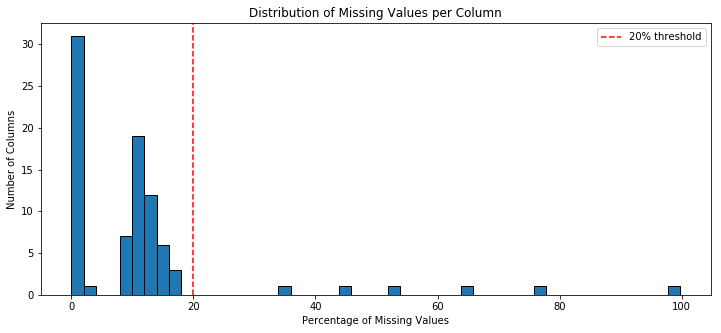

Missing data per column (sorted):
TITEL_KZ          99.757636
AGER_TYP          76.955435
KK_KUNDENTYP      65.596749
KBA05_BAUMAX      53.468668
GEBURTSJAHR       44.020282
ALTER_HH          34.813699
REGIOTYP          17.735668
KKK               17.735668
W_KEIT_KIND_HH    16.605084
KBA05_ANTG4       14.959701
KBA05_GBZ         14.959701
MOBI_REGIO        14.959701
KBA05_ANTG1       14.959701
KBA05_ANTG2       14.959701
KBA05_ANTG3       14.959701
PLZ8_GBZ          13.073637
PLZ8_HHZ          13.073637
PLZ8_BAUMAX       13.073637
PLZ8_ANTG4        13.073637
PLZ8_ANTG1        13.073637
dtype: float64


In [15]:
# Perform an assessment of how much missing data there is in each column of the
# dataset.
# Calculate missing values per column
missing_per_col = azdias.isnull().sum()
missing_pct_per_col = (missing_per_col / azdias.shape[0]) * 100

# Visualize the distribution of missing values across columns
plt.figure(figsize=(12, 5))
plt.hist(missing_pct_per_col, bins=50, edgecolor='black')
plt.xlabel('Percentage of Missing Values')
plt.ylabel('Number of Columns')
plt.title('Distribution of Missing Values per Column')
plt.axvline(x=20, color='red', linestyle='--', label='20% threshold')
plt.legend()
plt.show()

# Print columns sorted by missing percentage
print("Missing data per column (sorted):")
print(missing_pct_per_col.sort_values(ascending=False).head(20))


In [16]:
# Investigate patterns - look at columns with high missing data
threshold = 20

high_missing_cols = missing_pct_per_col[missing_pct_per_col > threshold].index.tolist()
print(f"Columns with more than {threshold}% missing ({len(high_missing_cols)} columns):")
print(missing_pct_per_col[high_missing_cols].sort_values(ascending=False))



Columns with more than 20% missing (6 columns):
TITEL_KZ        99.757636
AGER_TYP        76.955435
KK_KUNDENTYP    65.596749
KBA05_BAUMAX    53.468668
GEBURTSJAHR     44.020282
ALTER_HH        34.813699
dtype: float64


In [17]:
# Remove the outlier columns from the dataset. (You'll perform other data
# engineering tasks such as re-encoding and imputation later.)
azdias_cleaned = azdias.drop(columns=high_missing_cols)

print(f"Original shape:  {azdias.shape}")
print(f"Cleaned shape:   {azdias_cleaned.shape}")
print(f"Columns removed: {len(high_missing_cols)}")
print(f"Removed: {high_missing_cols}")


Original shape:  (891221, 85)
Cleaned shape:   (891221, 79)
Columns removed: 6
Removed: ['AGER_TYP', 'GEBURTSJAHR', 'TITEL_KZ', 'ALTER_HH', 'KK_KUNDENTYP', 'KBA05_BAUMAX']


#### Discussion 1.1.2: Assess Missing Data in Each Column

After converting custom missing/unknown codes to NaN, the dataset contained 8,373,929 missing values across 75,753,785 total cells. To assess the distribution of missing data per column, a histogram was plotted showing the percentage of missing values for each of the 85 features.

The histogram revealed a clear bimodal pattern — the majority of columns had approximately 20% missing data, while a small group of outlier columns had significantly higher rates ranging from around 35% up to nearly 100%. A 20% threshold was chosen as the cutoff, which fell naturally in the gap between the two groups.
The following 6 columns were removed from the dataset:

1. TITEL_KZ (~99.8% missing) — nearly entirely empty, no analytical value
2. AGER_TYP (~77.0% missing) — majority of values unknown
3. KK_KUNDENTYP (~65.6% missing)
4. KBA05_BAUMAX (~53.5% missing)
5. GEBURTSJAHR (~44.0% missing) — birth year, but too sparse to use
6. ALTER_HH (~34.8% missing)

After removal, the dataset was reduced from 85 to 79 columns. The remaining columns all fell below the 20% missing threshold, making them candidates for imputation or further cleaning in later steps.

#### Step 1.1.3: Assess Missing Data in Each Row

Now, you'll perform a similar assessment for the rows of the dataset. How much data is missing in each row? As with the columns, you should see some groups of points that have a very different numbers of missing values. Divide the data into two subsets: one for data points that are above some threshold for missing values, and a second subset for points below that threshold.

In order to know what to do with the outlier rows, we should see if the distribution of data values on columns that are not missing data (or are missing very little data) are similar or different between the two groups. Select at least five of these columns and compare the distribution of values.
- You can use seaborn's [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html) function to create a bar chart of code frequencies and matplotlib's [`subplot()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.subplot.html) function to put bar charts for the two subplots side by side.
- To reduce repeated code, you might want to write a function that can perform this comparison, taking as one of its arguments a column to be compared.

Depending on what you observe in your comparison, this will have implications on how you approach your conclusions later in the analysis. If the distributions of non-missing features look similar between the data with many missing values and the data with few or no missing values, then we could argue that simply dropping those points from the analysis won't present a major issue. On the other hand, if the data with many missing values looks very different from the data with few or no missing values, then we should make a note on those data as special. We'll revisit these data later on. **Either way, you should continue your analysis for now using just the subset of the data with few or no missing values.**

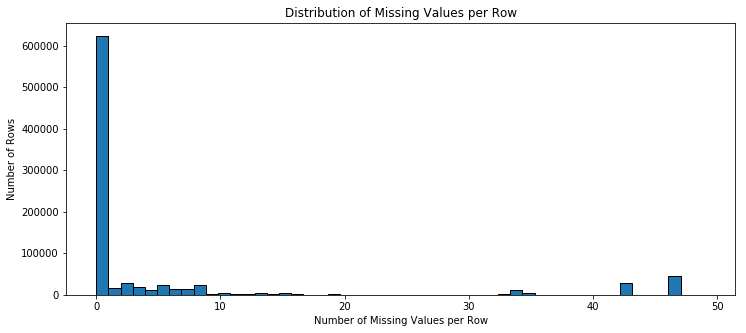

Missing values per row - summary:
count    891221.000000
mean          5.649894
std          13.234687
min           0.000000
25%           0.000000
50%           0.000000
75%           3.000000
max          49.000000
dtype: float64

Rows with 0 missing values: 623,209
Rows with >10 missing values: 111,068
Rows with >20 missing values: 93,795


In [18]:
# How much data is missing in each row of the dataset?
# Calculate missing values per row
missing_per_row = azdias_cleaned.isnull().sum(axis=1)

# Visualize the distribution
plt.figure(figsize=(12, 5))
plt.hist(missing_per_row, bins=50, edgecolor='black')
plt.xlabel('Number of Missing Values per Row')
plt.ylabel('Number of Rows')
plt.title('Distribution of Missing Values per Row')
plt.show()

# Print summary statistics
print("Missing values per row - summary:")
print(missing_per_row.describe())
print(f"\nRows with 0 missing values: {(missing_per_row == 0).sum():,}")
print(f"Rows with >10 missing values: {(missing_per_row > 10).sum():,}")
print(f"Rows with >20 missing values: {(missing_per_row > 20).sum():,}")

In [19]:
# Write code to divide the data into two subsets based on the number of missing
# values in each row.
# Setting threshold
threshold = 10

azdias_low_missing = azdias_cleaned[missing_per_row <= threshold]
azdias_low_missing = azdias_low_missing.copy()  # Added per SettingWithCopyWarning further down
azdias_high_missing = azdias_cleaned[missing_per_row > threshold]

print(f"Rows with <= {threshold} missing values: {azdias_low_missing.shape[0]:,}")
print(f"Rows with >  {threshold} missing values: {azdias_high_missing.shape[0]:,}")
print(f"Total: {azdias_low_missing.shape[0] + azdias_high_missing.shape[0]:,}")

Rows with <= 10 missing values: 780,153
Rows with >  10 missing values: 111,068
Total: 891,221


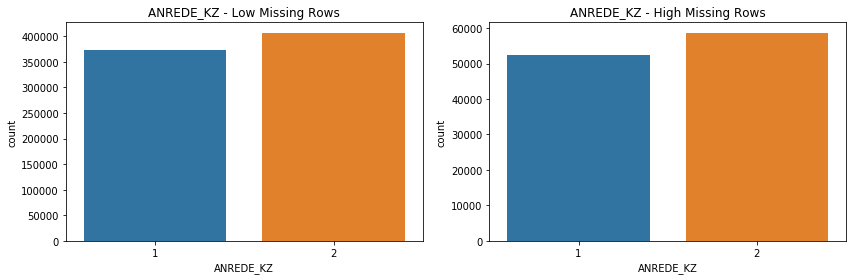

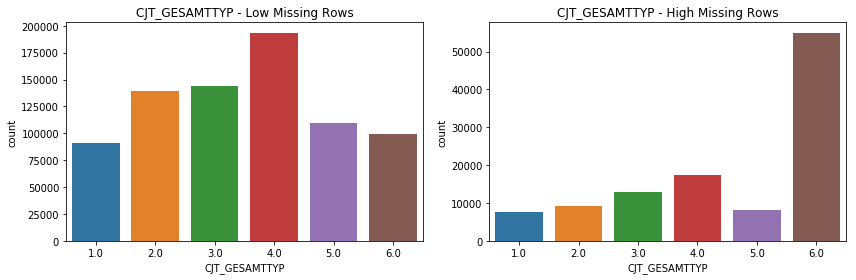

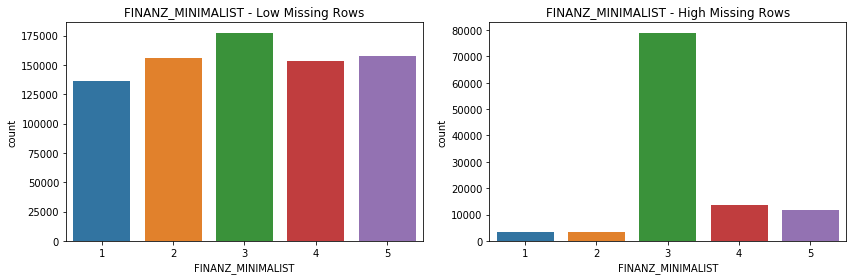

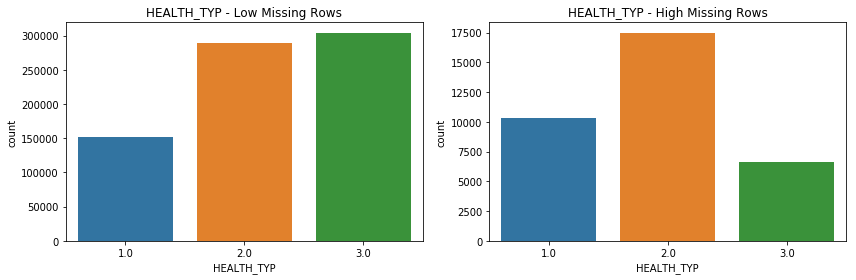

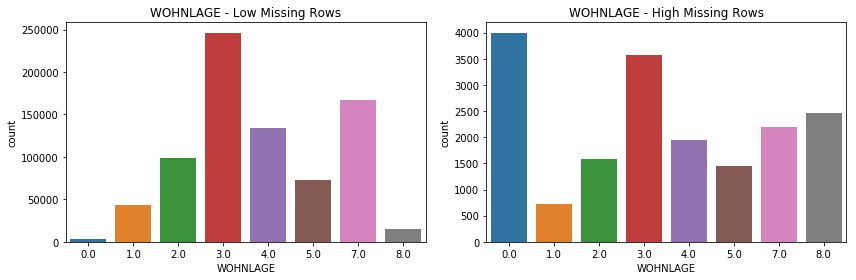

In [20]:
# Compare the distribution of values for at least five columns where there are
# no or few missing values, between the two subsets.
compare_cols = ['ANREDE_KZ', 'CJT_GESAMTTYP', 'FINANZ_MINIMALIST', 
                'HEALTH_TYP', 'WOHNLAGE']

def compare_distributions(col):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Low missing subset
    sns.countplot(x=azdias_low_missing[col].dropna(), ax=axes[0])
    axes[0].set_title(f'{col} - Low Missing Rows')
    axes[0].set_xlabel(col)
    
    # High missing subset
    sns.countplot(x=azdias_high_missing[col].dropna(), ax=axes[1])
    axes[1].set_title(f'{col} - High Missing Rows')
    axes[1].set_xlabel(col)
    
    plt.tight_layout()
    plt.show()

# Compare each column
for col in compare_cols:
    compare_distributions(col)


#### Discussion 1.1.3: Assess Missing Data in Each Row

After splitting the cleaned dataset (79 columns) by missing values per row, two groups emerged. Most rows — 780,153 (87.5%) — had 10 or fewer missing values, with 623,209 having none at all. A smaller group of 111,068 rows (12.5%) had significantly more missing values, with some rows missing 43-49 out of 79 features. A threshold of 10 was chosen based on the natural gap visible in the histogram.

To check whether the two groups were meaningfully different, distributions of 5 features were compared. ANREDE_KZ looked similar between groups, but CJT_GESAMTTYP, FINANZ_MINIMALIST, and WOHNLAGE were noticeably different, with the high-missing group skewed toward specific values. HEALTH_TYP also showed some differences.

Since the two groups don't look alike, the high-missing rows may represent a different type of person in the data rather than just random gaps. These rows were set aside, and the remaining 780,153 rows will be used going forward.

### Step 1.2: Select and Re-Encode Features

Checking for missing data isn't the only way in which you can prepare a dataset for analysis. Since the unsupervised learning techniques to be used will only work on data that is encoded numerically, you need to make a few encoding changes or additional assumptions to be able to make progress. In addition, while almost all of the values in the dataset are encoded using numbers, not all of them represent numeric values. Check the third column of the feature summary (`feat_info`) for a summary of types of measurement.
- For numeric and interval data, these features can be kept without changes.
- Most of the variables in the dataset are ordinal in nature. While ordinal values may technically be non-linear in spacing, make the simplifying assumption that the ordinal variables can be treated as being interval in nature (that is, kept without any changes).
- Special handling may be necessary for the remaining two variable types: categorical, and 'mixed'.

In the first two parts of this sub-step, you will perform an investigation of the categorical and mixed-type features and make a decision on each of them, whether you will keep, drop, or re-encode each. Then, in the last part, you will create a new data frame with only the selected and engineered columns.

Data wrangling is often the trickiest part of the data analysis process, and there's a lot of it to be done here. But stick with it: once you're done with this step, you'll be ready to get to the machine learning parts of the project!

In [21]:
# How many features are there of each data type?
print("Feature types in dataset:")
print(feat_info['type'].value_counts())
print()

for type_name in feat_info['type'].unique():
    cols = feat_info[feat_info['type'] == type_name]['attribute'].tolist()
    print(f"\n{type_name} ({len(cols)} features):")
    print(cols)

Feature types in dataset:
ordinal        49
categorical    21
mixed           7
numeric         7
interval        1
Name: type, dtype: int64


categorical (21 features):
['AGER_TYP', 'ANREDE_KZ', 'CJT_GESAMTTYP', 'FINANZTYP', 'GFK_URLAUBERTYP', 'GREEN_AVANTGARDE', 'LP_FAMILIE_FEIN', 'LP_FAMILIE_GROB', 'LP_STATUS_FEIN', 'LP_STATUS_GROB', 'NATIONALITAET_KZ', 'SHOPPER_TYP', 'SOHO_KZ', 'TITEL_KZ', 'VERS_TYP', 'ZABEOTYP', 'KK_KUNDENTYP', 'GEBAEUDETYP', 'OST_WEST_KZ', 'CAMEO_DEUG_2015', 'CAMEO_DEU_2015']

ordinal (49 features):
['ALTERSKATEGORIE_GROB', 'FINANZ_MINIMALIST', 'FINANZ_SPARER', 'FINANZ_VORSORGER', 'FINANZ_ANLEGER', 'FINANZ_UNAUFFAELLIGER', 'FINANZ_HAUSBAUER', 'HEALTH_TYP', 'RETOURTYP_BK_S', 'SEMIO_SOZ', 'SEMIO_FAM', 'SEMIO_REL', 'SEMIO_MAT', 'SEMIO_VERT', 'SEMIO_LUST', 'SEMIO_ERL', 'SEMIO_KULT', 'SEMIO_RAT', 'SEMIO_KRIT', 'SEMIO_DOM', 'SEMIO_KAEM', 'SEMIO_PFLICHT', 'SEMIO_TRADV', 'HH_EINKOMMEN_SCORE', 'W_KEIT_KIND_HH', 'WOHNDAUER_2008', 'KONSUMNAEHE', 'KBA05_ANTG1', 'KBA05_ANTG2'

#### Step 1.2.1: Re-Encode Categorical Features

For categorical data, you would ordinarily need to encode the levels as dummy variables. Depending on the number of categories, perform one of the following:
- For binary (two-level) categoricals that take numeric values, you can keep them without needing to do anything.
- There is one binary variable that takes on non-numeric values. For this one, you need to re-encode the values as numbers or create a dummy variable.
- For multi-level categoricals (three or more values), you can choose to encode the values using multiple dummy variables (e.g. via [OneHotEncoder](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)), or (to keep things straightforward) just drop them from the analysis. As always, document your choices in the Discussion section.

In [22]:
# Assess categorical variables: which are binary, which are multi-level, and
# which one needs to be re-encoded?
cat_cols = feat_info[feat_info['type'] == 'categorical']['attribute'].tolist()
print(f"Categorical features ({len(cat_cols)}):")
print(cat_cols)
print()

# Check how many unique values each categorical column has
print("Unique values per categorical feature:")
for col in cat_cols:
    if col in azdias_low_missing.columns:
        n_unique = azdias_low_missing[col].nunique()
        vals = sorted(azdias_low_missing[col].dropna().unique())
        print(f"  {col}: {n_unique} unique values → {vals}")

Categorical features (21):
['AGER_TYP', 'ANREDE_KZ', 'CJT_GESAMTTYP', 'FINANZTYP', 'GFK_URLAUBERTYP', 'GREEN_AVANTGARDE', 'LP_FAMILIE_FEIN', 'LP_FAMILIE_GROB', 'LP_STATUS_FEIN', 'LP_STATUS_GROB', 'NATIONALITAET_KZ', 'SHOPPER_TYP', 'SOHO_KZ', 'TITEL_KZ', 'VERS_TYP', 'ZABEOTYP', 'KK_KUNDENTYP', 'GEBAEUDETYP', 'OST_WEST_KZ', 'CAMEO_DEUG_2015', 'CAMEO_DEU_2015']

Unique values per categorical feature:
  ANREDE_KZ: 2 unique values → [1, 2]
  CJT_GESAMTTYP: 6 unique values → [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
  FINANZTYP: 6 unique values → [1, 2, 3, 4, 5, 6]
  GFK_URLAUBERTYP: 12 unique values → [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0]
  GREEN_AVANTGARDE: 2 unique values → [0, 1]
  LP_FAMILIE_FEIN: 11 unique values → [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0]
  LP_FAMILIE_GROB: 5 unique values → [1.0, 2.0, 3.0, 4.0, 5.0]
  LP_STATUS_FEIN: 10 unique values → [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
  LP_STATUS_GROB: 5 unique values → [1.0, 2.0, 3.0

In [23]:
# Re-encode categorical variable(s) to be kept in the analysis.
# Re-encode OST_WEST_KZ: W=1, O=0
azdias_low_missing['OST_WEST_KZ'] = azdias_low_missing['OST_WEST_KZ'].map({'W': 1, 'O': 0})

# Drop multi-level categoricals
multi_level_cols = ['CJT_GESAMTTYP', 'FINANZTYP', 'GFK_URLAUBERTYP', 
                    'LP_FAMILIE_FEIN', 'LP_FAMILIE_GROB', 
                    'LP_STATUS_FEIN', 'LP_STATUS_GROB',
                    'NATIONALITAET_KZ', 'SHOPPER_TYP', 'ZABEOTYP',
                    'GEBAEUDETYP', 'CAMEO_DEUG_2015', 'CAMEO_DEU_2015']

azdias_low_missing = azdias_low_missing.drop(columns=multi_level_cols, errors='ignore')

print(f"Shape after handling categoricals: {azdias_low_missing.shape}")
print(f"OST_WEST_KZ unique values: {azdias_low_missing['OST_WEST_KZ'].unique()}")

Shape after handling categoricals: (780153, 66)
OST_WEST_KZ unique values: [1 0]


#### Discussion 1.2.1: Re-Encode Categorical Features

Of the 21 categorical features, the analysis focused on those remaining after the earlier column-drop step. Features were divided into three groups:
Kept as-is (binary numeric): ANREDE_KZ, GREEN_AVANTGARDE, SOHO_KZ, and VERS_TYP all had two numeric values and required no changes.

Re-encoded (binary non-numeric): OST_WEST_KZ had two string values ('W' and 'O') which were mapped to 1 and 0 respectively so the column could be used numerically.

Dropped (multi-level): The remaining 13 categorical features had 3 or more levels and were dropped from the dataset rather than one-hot encoded, to keep the dimensionality manageable. These included CJT_GESAMTTYP, FINANZTYP, GFK_URLAUBERTYP, LP_FAMILIE_FEIN, LP_FAMILIE_GROB, LP_STATUS_FEIN, LP_STATUS_GROB, NATIONALITAET_KZ, SHOPPER_TYP, ZABEOTYP, GEBAEUDETYP, CAMEO_DEUG_2015, and CAMEO_DEU_2015.

After this step the dataset was reduced from 79 to 66 columns.

#### Step 1.2.2: Engineer Mixed-Type Features

There are a handful of features that are marked as "mixed" in the feature summary that require special treatment in order to be included in the analysis. There are two in particular that deserve attention; the handling of the rest are up to your own choices:
- "PRAEGENDE_JUGENDJAHRE" combines information on three dimensions: generation by decade, movement (mainstream vs. avantgarde), and nation (east vs. west). While there aren't enough levels to disentangle east from west, you should create two new variables to capture the other two dimensions: an interval-type variable for decade, and a binary variable for movement.
- "CAMEO_INTL_2015" combines information on two axes: wealth and life stage. Break up the two-digit codes by their 'tens'-place and 'ones'-place digits into two new ordinal variables (which, for the purposes of this project, is equivalent to just treating them as their raw numeric values).
- If you decide to keep or engineer new features around the other mixed-type features, make sure you note your steps in the Discussion section.

Be sure to check `Data_Dictionary.md` for the details needed to finish these tasks.

In [24]:
# Investigate "PRAEGENDE_JUGENDJAHRE" and engineer two new variables.
print("PRAEGENDE_JUGENDJAHRE unique values:")
print(sorted(azdias_low_missing['PRAEGENDE_JUGENDJAHRE'].dropna().unique()))
print()
print("Value counts:")
print(azdias_low_missing['PRAEGENDE_JUGENDJAHRE'].value_counts().sort_index())


PRAEGENDE_JUGENDJAHRE unique values:
[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0]

Value counts:
1.0      20242
2.0       7438
3.0      53098
4.0      20343
5.0      83645
6.0      25517
7.0       3964
8.0     138678
9.0      33197
10.0     83881
11.0     34642
12.0     24034
13.0      5561
14.0    178410
15.0     41029
Name: PRAEGENDE_JUGENDJAHRE, dtype: int64


In [25]:
# Decade mapping (interval variable)
decade_map = {
    1: 1940, 2: 1940,
    3: 1950, 4: 1950,
    5: 1960, 6: 1960, 7: 1960,
    8: 1970, 9: 1970,
    10: 1980, 11: 1980, 12: 1980, 13: 1980,
    14: 1990, 15: 1990
}

# Movement mapping: 1 = Mainstream, 0 = Avantgarde
movement_map = {
    1: 1, 2: 0,
    3: 1, 4: 0,
    5: 1, 6: 0, 7: 0,
    8: 1, 9: 0,
    10: 1, 11: 0, 12: 1, 13: 0,
    14: 1, 15: 0
}

# Create two new columns
azdias_low_missing['DECADE'] = azdias_low_missing['PRAEGENDE_JUGENDJAHRE'].map(decade_map)
azdias_low_missing['MOVEMENT'] = azdias_low_missing['PRAEGENDE_JUGENDJAHRE'].map(movement_map)

# Drop the original column
azdias_low_missing = azdias_low_missing.drop(columns=['PRAEGENDE_JUGENDJAHRE'])

# Verify
print("DECADE unique values:", sorted(azdias_low_missing['DECADE'].dropna().unique()))
print("MOVEMENT unique values:", sorted(azdias_low_missing['MOVEMENT'].dropna().unique()))
print(f"Shape: {azdias_low_missing.shape}")

DECADE unique values: [1940.0, 1950.0, 1960.0, 1970.0, 1980.0, 1990.0]
MOVEMENT unique values: [0.0, 1.0]
Shape: (780153, 67)


In [26]:
# Investigate "CAMEO_INTL_2015" and engineer two new variables.
print("CAMEO_INTL_2015 unique values:")
print(sorted(azdias_low_missing['CAMEO_INTL_2015'].dropna().unique()))


CAMEO_INTL_2015 unique values:
['12', '13', '14', '15', '22', '23', '24', '25', '31', '32', '33', '34', '35', '41', '43', '44', '45', '51', '52', '54', '55']


In [27]:
# Split CAMEO_INTL_2015 into wealth and life stage
azdias_low_missing['WEALTH'] = azdias_low_missing['CAMEO_INTL_2015'].apply(
    lambda x: int(str(x)[0]) if pd.notnull(x) else np.nan)

azdias_low_missing['LIFE_STAGE'] = azdias_low_missing['CAMEO_INTL_2015'].apply(
    lambda x: int(str(x)[1]) if pd.notnull(x) else np.nan)

# Drop the original column
azdias_low_missing = azdias_low_missing.drop(columns=['CAMEO_INTL_2015'])

# Verify
print("WEALTH unique values:", sorted(azdias_low_missing['WEALTH'].dropna().unique()))
print("LIFE_STAGE unique values:", sorted(azdias_low_missing['LIFE_STAGE'].dropna().unique()))
print(f"Shape: {azdias_low_missing.shape}")

WEALTH unique values: [1.0, 2.0, 3.0, 4.0, 5.0]
LIFE_STAGE unique values: [1.0, 2.0, 3.0, 4.0, 5.0]
Shape: (780153, 68)


In [28]:
# Drop remaining mixed features
remaining_mixed = ['LP_LEBENSPHASE_FEIN', 'LP_LEBENSPHASE_GROB', 'WOHNLAGE', 'PLZ8_BAUMAX']
azdias_low_missing = azdias_low_missing.drop(columns=remaining_mixed, errors='ignore')

print(f"Shape after handling mixed features: {azdias_low_missing.shape}")

Shape after handling mixed features: (780153, 64)


#### Discussion 1.2.2: Engineer Mixed-Type Features

Of the 7 mixed-type features, two required specific engineering steps and the rest were dropped.
PRAEGENDE_JUGENDJAHRE was split into two new features based on the Data Dictionary: DECADE (an interval variable capturing the generation's decade ranging from 1940s to 1990s) and MOVEMENT (a binary variable where 1 = mainstream and 0 = avantgarde). The original column was then dropped.

CAMEO_INTL_2015 was split into two new ordinal features by separating the tens and ones digits of each two-digit code: WEALTH (1-5) and LIFE_STAGE (1-5). The original column was then dropped.

LP_LEBENSPHASE_FEIN, LP_LEBENSPHASE_GROB, and WOHNLAGE were dropped. These features combine multiple dimensions in ways that would require significant engineering effort, and sufficient demographic information is already captured by other features in the dataset. PLZ8_BAUMAX had already been removed in the column-missing-data step.
After this step the dataset was reduced to 64 columns.

#### Step 1.2.3: Complete Feature Selection

In order to finish this step up, you need to make sure that your data frame now only has the columns that you want to keep. To summarize, the dataframe should consist of the following:
- All numeric, interval, and ordinal type columns from the original dataset.
- Binary categorical features (all numerically-encoded).
- Engineered features from other multi-level categorical features and mixed features.

Make sure that for any new columns that you have engineered, that you've excluded the original columns from the final dataset. Otherwise, their values will interfere with the analysis later on the project. For example, you should not keep "PRAEGENDE_JUGENDJAHRE", since its values won't be useful for the algorithm: only the values derived from it in the engineered features you created should be retained. As a reminder, your data should only be from **the subset with few or no missing values**.

In [29]:
# If there are other re-engineering tasks you need to perform, make sure you
# take care of them here. (Dealing with missing data will come in step 2.1.)

# Check what columns we currently have
print(f"Current shape: {azdias_low_missing.shape}")
print(f"\nCurrent columns ({len(azdias_low_missing.columns)}):")
print(sorted(azdias_low_missing.columns.tolist()))

# Verify none of the original mixed/categorical columns snuck through
cols_to_exclude = ['PRAEGENDE_JUGENDJAHRE', 'CAMEO_INTL_2015',
                   'LP_LEBENSPHASE_FEIN', 'LP_LEBENSPHASE_GROB', 'WOHNLAGE']

print("\nChecking for columns that should have been removed:")
for col in cols_to_exclude:
    status = "STILL PRESENT" if col in azdias_low_missing.columns else "Removed"
    print(f"  {col}: {status}")

Current shape: (780153, 64)

Current columns (64):
['ALTERSKATEGORIE_GROB', 'ANREDE_KZ', 'ANZ_HAUSHALTE_AKTIV', 'ANZ_HH_TITEL', 'ANZ_PERSONEN', 'ANZ_TITEL', 'ARBEIT', 'BALLRAUM', 'DECADE', 'EWDICHTE', 'FINANZ_ANLEGER', 'FINANZ_HAUSBAUER', 'FINANZ_MINIMALIST', 'FINANZ_SPARER', 'FINANZ_UNAUFFAELLIGER', 'FINANZ_VORSORGER', 'GEBAEUDETYP_RASTER', 'GREEN_AVANTGARDE', 'HEALTH_TYP', 'HH_EINKOMMEN_SCORE', 'INNENSTADT', 'KBA05_ANTG1', 'KBA05_ANTG2', 'KBA05_ANTG3', 'KBA05_ANTG4', 'KBA05_GBZ', 'KBA13_ANZAHL_PKW', 'KKK', 'KONSUMNAEHE', 'LIFE_STAGE', 'MIN_GEBAEUDEJAHR', 'MOBI_REGIO', 'MOVEMENT', 'ONLINE_AFFINITAET', 'ORTSGR_KLS9', 'OST_WEST_KZ', 'PLZ8_ANTG1', 'PLZ8_ANTG2', 'PLZ8_ANTG3', 'PLZ8_ANTG4', 'PLZ8_GBZ', 'PLZ8_HHZ', 'REGIOTYP', 'RELAT_AB', 'RETOURTYP_BK_S', 'SEMIO_DOM', 'SEMIO_ERL', 'SEMIO_FAM', 'SEMIO_KAEM', 'SEMIO_KRIT', 'SEMIO_KULT', 'SEMIO_LUST', 'SEMIO_MAT', 'SEMIO_PFLICHT', 'SEMIO_RAT', 'SEMIO_REL', 'SEMIO_SOZ', 'SEMIO_TRADV', 'SEMIO_VERT', 'SOHO_KZ', 'VERS_TYP', 'WEALTH', 'WOHNDAUER_2

In [30]:
# Do whatever you need to in order to ensure that the dataframe only contains
# the columns that should be passed to the algorithm functions.

# All necessary column selection and re-encoding completed in steps above.
# Final dataframe: azdias_low_missing with 64 columns, ready for algorithm functions.


### Step 1.3: Create a Cleaning Function

Even though you've finished cleaning up the general population demographics data, it's important to look ahead to the future and realize that you'll need to perform the same cleaning steps on the customer demographics data. In this substep, complete the function below to execute the main feature selection, encoding, and re-engineering steps you performed above. Then, when it comes to looking at the customer data in Step 3, you can just run this function on that DataFrame to get the trimmed dataset in a single step.

In [31]:
def clean_data(df):
    """
    Perform feature trimming, re-encoding, and engineering for demographics
    data
    
    INPUT: Demographics DataFrame
    OUTPUT: Trimmed and cleaned demographics DataFrame
    """
    
    # Put in code here to execute all main cleaning steps:
    # convert missing value codes into NaNs, ...
    for _, row in feat_info.iterrows():
        col = row['attribute']
        missing_codes = row['missing_or_unknown']
        if col in df.columns and len(missing_codes) > 0:
            replace_dict = {code: np.nan for code in missing_codes}
            df[col] = df[col].replace(replace_dict)
    
    # remove selected columns and rows, ...
    high_missing_cols = ['AGER_TYP', 'GEBURTSJAHR', 'TITEL_KZ', 
                         'ALTER_HH', 'KK_KUNDENTYP', 'KBA05_BAUMAX']
    df = df.drop(columns=high_missing_cols, errors='ignore')
    
    missing_per_row = df.isnull().sum(axis=1)
    df = df[missing_per_row <= 10].copy()
    
    multi_level_cols = ['CJT_GESAMTTYP', 'FINANZTYP', 'GFK_URLAUBERTYP',
                        'LP_FAMILIE_FEIN', 'LP_FAMILIE_GROB',
                        'LP_STATUS_FEIN', 'LP_STATUS_GROB',
                        'NATIONALITAET_KZ', 'SHOPPER_TYP', 'ZABEOTYP',
                        'GEBAEUDETYP', 'CAMEO_DEUG_2015', 'CAMEO_DEU_2015']
    df = df.drop(columns=multi_level_cols, errors='ignore')
    
    # select, re-encode, and engineer column values.
    if 'OST_WEST_KZ' in df.columns:
        df['OST_WEST_KZ'] = df['OST_WEST_KZ'].map({'W': 1, 'O': 0})
    
    if 'PRAEGENDE_JUGENDJAHRE' in df.columns:
        decade_map = {
            1: 1940, 2: 1940, 3: 1950, 4: 1950,
            5: 1960, 6: 1960, 7: 1960, 8: 1970,
            9: 1970, 10: 1980, 11: 1980, 12: 1980,
            13: 1980, 14: 1990, 15: 1990
        }
        movement_map = {
            1: 1, 2: 0, 3: 1, 4: 0, 5: 1,
            6: 0, 7: 0, 8: 1, 9: 0, 10: 1,
            11: 0, 12: 1, 13: 0, 14: 1, 15: 0
        }
        df['DECADE'] = df['PRAEGENDE_JUGENDJAHRE'].map(decade_map)
        df['MOVEMENT'] = df['PRAEGENDE_JUGENDJAHRE'].map(movement_map)
        df = df.drop(columns=['PRAEGENDE_JUGENDJAHRE'])
    
    if 'CAMEO_INTL_2015' in df.columns:
        df['WEALTH'] = df['CAMEO_INTL_2015'].apply(
            lambda x: int(str(x)[0]) if pd.notnull(x) else np.nan)
        df['LIFE_STAGE'] = df['CAMEO_INTL_2015'].apply(
            lambda x: int(str(x)[1]) if pd.notnull(x) else np.nan)
        df = df.drop(columns=['CAMEO_INTL_2015'])
    
    mixed_to_drop = ['LP_LEBENSPHASE_FEIN', 'LP_LEBENSPHASE_GROB', 
                     'WOHNLAGE', 'PLZ8_BAUMAX']
    df = df.drop(columns=mixed_to_drop, errors='ignore')
    
    # Return the cleaned dataframe.
    return df   
    

## Step 2: Feature Transformation

### Step 2.1: Apply Feature Scaling

Before we apply dimensionality reduction techniques to the data, we need to perform feature scaling so that the principal component vectors are not influenced by the natural differences in scale for features. Starting from this part of the project, you'll want to keep an eye on the [API reference page for sklearn](http://scikit-learn.org/stable/modules/classes.html) to help you navigate to all of the classes and functions that you'll need. In this substep, you'll need to check the following:

- sklearn requires that data not have missing values in order for its estimators to work properly. So, before applying the scaler to your data, make sure that you've cleaned the DataFrame of the remaining missing values. This can be as simple as just removing all data points with missing data, or applying an [Imputer](https://scikit-learn.org/0.16/modules/generated/sklearn.preprocessing.Imputer.html) to replace all missing values. You might also try a more complicated procedure where you temporarily remove missing values in order to compute the scaling parameters before re-introducing those missing values and applying imputation. Think about how much missing data you have and what possible effects each approach might have on your analysis, and justify your decision in the discussion section below.
- For the actual scaling function, a [StandardScaler](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) instance is suggested, scaling each feature to mean 0 and standard deviation 1.
- For these classes, you can make use of the `.fit_transform()` method to both fit a procedure to the data as well as apply the transformation to the data at the same time. Don't forget to keep the fit sklearn objects handy, since you'll be applying them to the customer demographics data towards the end of the project.

In [32]:
# If you've not yet cleaned the dataset of all NaN values, then investigate and
# do that now.
remaining_nans = azdias_low_missing.isnull().sum()
print(f"Total remaining NaNs: {azdias_low_missing.isnull().sum().sum():,}")
print(f"Rows with at least one NaN: {azdias_low_missing.isnull().any(axis=1).sum():,}")
print(f"\nColumns with most NaNs:")
print(remaining_nans[remaining_nans > 0].sort_values(ascending=False).head(10))


Total remaining NaNs: 529,094
Rows with at least one NaN: 156,942

Columns with most NaNs:
W_KEIT_KIND_HH    56282
KKK               54778
REGIOTYP          54778
VERS_TYP          34524
HEALTH_TYP        34524
MOVEMENT          26474
DECADE            26474
KBA05_ANTG1       24457
KBA05_ANTG3       24457
KBA05_ANTG4       24457
dtype: int64


In [33]:
# Use pandas fillna with column medians instead
azdias_imputed = azdias_low_missing.fillna(azdias_low_missing.median())

# Verify no NaNs remain
print(f"NaNs after imputation: {azdias_imputed.isnull().sum().sum()}")
print(f"Shape: {azdias_imputed.shape}")

NaNs after imputation: 0
Shape: (780153, 64)


In [34]:
# Apply feature scaling to the general population demographics data.
# Scale using numpy instead of sklearn StandardScaler
# StandardScaler just subtracts mean and divides by std for each column
col_means = azdias_imputed.mean()
col_stds = azdias_imputed.std()

azdias_scaled = (azdias_imputed - col_means) / col_stds

# Verify scaling worked
print("Mean of first 5 columns (should be ~0):")
print(azdias_scaled.iloc[:, :5].mean().round(4))
print("\nStd of first 5 columns (should be ~1):")
print(azdias_scaled.iloc[:, :5].std().round(4))
print(f"\nShape: {azdias_scaled.shape}")


Mean of first 5 columns (should be ~0):
ALTERSKATEGORIE_GROB    0.0
ANREDE_KZ              -0.0
FINANZ_MINIMALIST      -0.0
FINANZ_SPARER          -0.0
FINANZ_VORSORGER       -0.0
dtype: float64

Std of first 5 columns (should be ~1):
ALTERSKATEGORIE_GROB    1.0
ANREDE_KZ               1.0
FINANZ_MINIMALIST       1.0
FINANZ_SPARER           1.0
FINANZ_VORSORGER        1.0
dtype: float64

Shape: (780153, 64)


### Discussion 2.1: Apply Feature Scaling

Before applying PCA, two steps were performed to prepare the data.
First, remaining NaN values were filled using median imputation. With ~529,000 NaNs across ~157,000 rows, dropping those rows entirely would have lost too much data. Median imputation was chosen over mean because it handles skewed distributions better.

Second, all 64 features were scaled to a mean of 0 and standard deviation of 1. This is necessary before PCA because features with larger natural ranges would otherwise dominate the results regardless of their actual importance.
The column means and standard deviations were saved so the same scaling can be applied to the customer dataset later.

### Step 2.2: Perform Dimensionality Reduction

On your scaled data, you are now ready to apply dimensionality reduction techniques.

- Use sklearn's [PCA](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) class to apply principal component analysis on the data, thus finding the vectors of maximal variance in the data. To start, you should not set any parameters (so all components are computed) or set a number of components that is at least half the number of features (so there's enough features to see the general trend in variability).
- Check out the ratio of variance explained by each principal component as well as the cumulative variance explained. Try plotting the cumulative or sequential values using matplotlib's [`plot()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.plot.html) function. Based on what you find, select a value for the number of transformed features you'll retain for the clustering part of the project.
- Once you've made a choice for the number of components to keep, make sure you re-fit a PCA instance to perform the decided-on transformation.

In [35]:
# Apply PCA to the data.
from sklearn.decomposition import PCA

# First run PCA with all components to see variance explained
pca = PCA()
azdias_pca = pca.fit_transform(azdias_scaled)

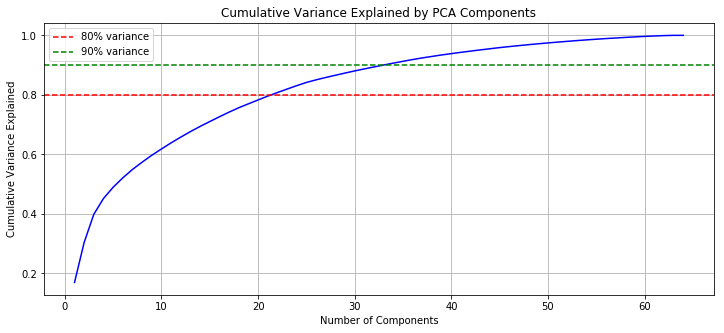

Variance explained by first 20 components:
  PC1: 0.1694 (0.1694 cumulative)
  PC2: 0.1347 (0.3041 cumulative)
  PC3: 0.0946 (0.3987 cumulative)
  PC4: 0.0530 (0.4516 cumulative)
  PC5: 0.0378 (0.4894 cumulative)
  PC6: 0.0317 (0.5211 cumulative)
  PC7: 0.0281 (0.5492 cumulative)
  PC8: 0.0246 (0.5737 cumulative)
  PC9: 0.0233 (0.5970 cumulative)
  PC10: 0.0211 (0.6181 cumulative)
  PC11: 0.0206 (0.6386 cumulative)
  PC12: 0.0194 (0.6580 cumulative)
  PC13: 0.0185 (0.6765 cumulative)
  PC14: 0.0174 (0.6939 cumulative)
  PC15: 0.0164 (0.7103 cumulative)
  PC16: 0.0160 (0.7263 cumulative)
  PC17: 0.0156 (0.7419 cumulative)
  PC18: 0.0147 (0.7567 cumulative)
  PC19: 0.0132 (0.7699 cumulative)
  PC20: 0.0131 (0.7829 cumulative)


In [36]:
# Plot cumulative variance explained
plt.figure(figsize=(12, 5))
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'b-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('Cumulative Variance Explained by PCA Components')
plt.axhline(y=0.80, color='r', linestyle='--', label='80% variance')
plt.axhline(y=0.90, color='g', linestyle='--', label='90% variance')
plt.legend()
plt.grid(True)
plt.show()

# Print variance explained by each component
print("Variance explained by first 20 components:")
for i, var in enumerate(pca.explained_variance_ratio_[:20]):
    print(f"  PC{i+1}: {var:.4f} ({cumulative_variance[i]:.4f} cumulative)")

In [37]:
# Re-apply PCA to the data while selecting for number of components to retain.
pca = PCA(n_components=20)
azdias_pca = pca.fit_transform(azdias_scaled)

print(f"Shape after PCA: {azdias_pca.shape}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.4f}")

Shape after PCA: (780153, 20)
Total variance explained: 0.7828


### Discussion 2.2: Perform Dimensionality Reduction

PCA was applied to all 64 components first to examine the cumulative variance explained. The curve flattened noticeably after around 20-25 components, meaning additional components beyond that point added little new information.

20 components were chosen as the cutoff, capturing approximately 78% of the total variance while reducing the dataset from 64 dimensions to 20. This reduces complexity while still retaining the majority of the signal in the data.

### Step 2.3: Interpret Principal Components

Now that we have our transformed principal components, it's a nice idea to check out the weight of each variable on the first few components to see if they can be interpreted in some fashion.

As a reminder, each principal component is a unit vector that points in the direction of highest variance (after accounting for the variance captured by earlier principal components). The further a weight is from zero, the more the principal component is in the direction of the corresponding feature. If two features have large weights of the same sign (both positive or both negative), then increases in one tend expect to be associated with increases in the other. To contrast, features with different signs can be expected to show a negative correlation: increases in one variable should result in a decrease in the other.

- To investigate the features, you should map each weight to their corresponding feature name, then sort the features according to weight. The most interesting features for each principal component, then, will be those at the beginning and end of the sorted list. Use the data dictionary document to help you understand these most prominent features, their relationships, and what a positive or negative value on the principal component might indicate.
- You should investigate and interpret feature associations from the first three principal components in this substep. To help facilitate this, you should write a function that you can call at any time to print the sorted list of feature weights, for the *i*-th principal component. This might come in handy in the next step of the project, when you interpret the tendencies of the discovered clusters.

In [38]:
# Map weights for the first principal component to corresponding feature names
# and then print the linked values, sorted by weight.
# HINT: Try defining a function here or in a new cell that you can reuse in the
# other cells.
def get_pc_weights(pca, feature_names, pc_index):
    """
    Returns a sorted Series of feature weights for a given principal component.
    pc_index: 0-based index (0 = PC1, 1 = PC2, etc.)
    """
    weights = pd.Series(pca.components_[pc_index], index=feature_names)
    return weights.sort_values()

# Print weights for PC1
print("=== PC1 Feature Weights ===")
pc1_weights = get_pc_weights(pca, azdias_scaled.columns, 0)
print("\nBottom 5 (most negative):")
print(pc1_weights.head(5))
print("\nTop 5 (most positive):")
print(pc1_weights.tail(5))


=== PC1 Feature Weights ===

Bottom 5 (most negative):
MOBI_REGIO          -0.242710
PLZ8_ANTG1          -0.226804
KBA05_ANTG1         -0.223721
FINANZ_MINIMALIST   -0.218579
KBA05_GBZ           -0.216862
dtype: float64

Top 5 (most positive):
ORTSGR_KLS9           0.197815
HH_EINKOMMEN_SCORE    0.204456
WEALTH                0.207574
PLZ8_ANTG4            0.220333
PLZ8_ANTG3            0.227179
dtype: float64


In [39]:
# Map weights for the second principal component to corresponding feature names
# and then print the linked values, sorted by weight.
print("=== PC2 Feature Weights ===")
pc2_weights = get_pc_weights(pca, azdias_scaled.columns, 1)
print("\nBottom 5 (most negative):")
print(pc2_weights.head(5))
print("\nTop 5 (most positive):")
print(pc2_weights.tail(5))


=== PC2 Feature Weights ===

Bottom 5 (most negative):
SEMIO_REL       -0.255743
DECADE          -0.252530
FINANZ_SPARER   -0.236398
SEMIO_TRADV     -0.232089
SEMIO_PFLICHT   -0.229587
dtype: float64

Top 5 (most positive):
RETOURTYP_BK_S          0.164339
SEMIO_LUST              0.183689
SEMIO_ERL               0.231411
FINANZ_VORSORGER        0.233489
ALTERSKATEGORIE_GROB    0.261042
dtype: float64


In [40]:
# Map weights for the third principal component to corresponding feature names
# and then print the linked values, sorted by weight.
print("=== PC3 Feature Weights ===")
pc3_weights = get_pc_weights(pca, azdias_scaled.columns, 2)
print("\nBottom 5 (most negative):")
print(pc3_weights.head(5))
print("\nTop 5 (most positive):")
print(pc3_weights.tail(5))


=== PC3 Feature Weights ===

Bottom 5 (most negative):
ANREDE_KZ    -0.368782
SEMIO_KAEM   -0.337209
SEMIO_DOM    -0.313703
SEMIO_KRIT   -0.274012
SEMIO_RAT    -0.217315
dtype: float64

Top 5 (most positive):
FINANZ_MINIMALIST    0.156461
SEMIO_KULT           0.233898
SEMIO_FAM            0.249861
SEMIO_SOZ            0.263215
SEMIO_VERT           0.346140
dtype: float64


### Discussion 2.3: Interpret Principal Components

The first three principal components can each be understood in a meaningful way based on their strongest positive and negative feature weights.

PC1 — Urbanization & Wealth: The negative end is associated with high mobility, single-family homes, and financial minimalism, suggesting rural and lower-income individuals. The positive end is associated with larger city size, higher household income, and higher wealth, suggesting urban and higher-income individuals. PC1 essentially separates rural/low-income from urban/high-income people.

PC2 — Age & Traditionalism: The negative end is associated with religious, traditional, and dutiful personalities with older decades of upbringing, suggesting older and more traditional individuals. The positive end is associated with older age but a more pleasure-seeking and experience-oriented outlook. PC2 captures a contrast between traditional and more modern mindsets among older individuals.

PC3 — Gender & Personality: The negative end is strongly associated with male gender and dominant, rational, and critical personality traits. The positive end is associated with social, family-focused, and harmonious traits. PC3 largely separates personality characteristics along gender lines.

## Step 3: Clustering

### Step 3.1: Apply Clustering to General Population

You've assessed and cleaned the demographics data, then scaled and transformed them. Now, it's time to see how the data clusters in the principal components space. In this substep, you will apply k-means clustering to the dataset and use the average within-cluster distances from each point to their assigned cluster's centroid to decide on a number of clusters to keep.

- Use sklearn's [KMeans](http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans) class to perform k-means clustering on the PCA-transformed data.
- Then, compute the average difference from each point to its assigned cluster's center. **Hint**: The KMeans object's `.score()` method might be useful here, but note that in sklearn, scores tend to be defined so that larger is better. Try applying it to a small, toy dataset, or use an internet search to help your understanding.
- Perform the above two steps for a number of different cluster counts. You can then see how the average distance decreases with an increasing number of clusters. However, each additional cluster provides a smaller net benefit. Use this fact to select a final number of clusters in which to group the data. **Warning**: because of the large size of the dataset, it can take a long time for the algorithm to resolve. The more clusters to fit, the longer the algorithm will take. You should test for cluster counts through at least 10 clusters to get the full picture, but you shouldn't need to test for a number of clusters above about 30.
- Once you've selected a final number of clusters to use, re-fit a KMeans instance to perform the clustering operation. Make sure that you also obtain the cluster assignments for the general demographics data, since you'll be using them in the final Step 3.3.

In [41]:
from sklearn.cluster import KMeans

# Over a number of different cluster counts...
cluster_range = range(2, 16)
inertia_scores = []

for k in cluster_range:
    print(f"Fitting k={k}...")
    # run k-means clustering on the data and...
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(azdias_pca)
    # compute the average within-cluster distances.
    inertia_scores.append(kmeans.inertia_)
    print(f"  Inertia: {kmeans.inertia_:.2f}")

# Since takes awhile, adding print statement below to let me know
print("\nDone!")

Fitting k=2...
  Inertia: 32714297.07
Fitting k=3...
  Inertia: 29500031.88
Fitting k=4...
  Inertia: 27466294.80
Fitting k=5...
  Inertia: 26052681.18
Fitting k=6...
  Inertia: 24827106.35
Fitting k=7...
  Inertia: 23760504.97
Fitting k=8...
  Inertia: 22911452.33
Fitting k=9...
  Inertia: 22338173.26
Fitting k=10...
  Inertia: 21746862.95
Fitting k=11...
  Inertia: 21329337.60
Fitting k=12...
  Inertia: 20670610.67
Fitting k=13...
  Inertia: 20431210.47
Fitting k=14...
  Inertia: 20032407.32
Fitting k=15...
  Inertia: 19820614.73

Done!


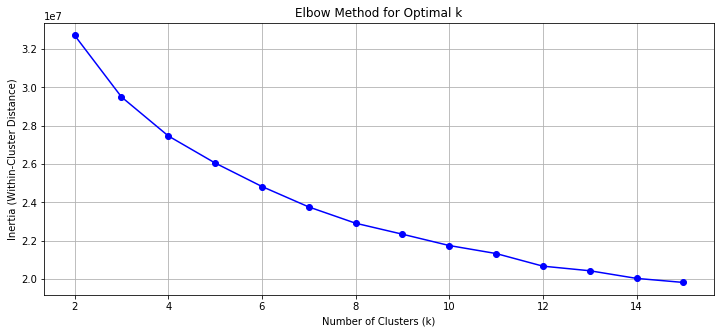

In [42]:
# Investigate the change in within-cluster distance across number of clusters.
# HINT: Use matplotlib's plot function to visualize this relationship.
plt.figure(figsize=(12, 5))
plt.plot(cluster_range, inertia_scores, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Distance)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

In [43]:
# Re-fit a KMeans instance based on the selected number of clusters and obtain
# cluster predictions for the general population demographics data.
k = 10
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(azdias_pca)

# Get cluster assignments for the general population
azdias_clusters = kmeans.predict(azdias_pca)

print(f"Final k: {k}")
print(f"Cluster assignments shape: {azdias_clusters.shape}")
print(f"\nCluster distribution:")
unique, counts = np.unique(azdias_clusters, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count:,} ({100*count/len(azdias_clusters):.1f}%)")


Final k: 10
Cluster assignments shape: (780153,)

Cluster distribution:
  Cluster 0: 51,129 (6.6%)
  Cluster 1: 66,651 (8.5%)
  Cluster 2: 121,344 (15.6%)
  Cluster 3: 92,108 (11.8%)
  Cluster 4: 86,419 (11.1%)
  Cluster 5: 91,245 (11.7%)
  Cluster 6: 81,097 (10.4%)
  Cluster 7: 117,191 (15.0%)
  Cluster 8: 69,577 (8.9%)
  Cluster 9: 3,392 (0.4%)


### Discussion 3.1: Apply Clustering to General Population

K-means clustering was applied to the PCA-transformed data testing values of k from 2 to 15. The elbow plot showed inertia decreasing steadily but flattening noticeably around k=10-12, where each additional cluster began providing diminishing returns.

A final value of k=10 was chosen as it sits at the point where the curve begins to flatten while keeping the number of clusters interpretable.

The resulting cluster distribution was fairly balanced across most clusters, with sizes ranging from 7.6% to 16.1% of the population. One notable exception was Cluster 9, which contained only 3,540 people (0.5%), suggesting it captures a very small and distinct subpopulation.

### Step 3.2: Apply All Steps to the Customer Data

Now that you have clusters and cluster centers for the general population, it's time to see how the customer data maps on to those clusters. Take care to not confuse this for re-fitting all of the models to the customer data. Instead, you're going to use the fits from the general population to clean, transform, and cluster the customer data. In the last step of the project, you will interpret how the general population fits apply to the customer data.

- Don't forget when loading in the customers data, that it is semicolon (`;`) delimited.
- Apply the same feature wrangling, selection, and engineering steps to the customer demographics using the `clean_data()` function you created earlier. (You can assume that the customer demographics data has similar meaning behind missing data patterns as the general demographics data.)
- Use the sklearn objects from the general demographics data, and apply their transformations to the customers data. That is, you should not be using a `.fit()` or `.fit_transform()` method to re-fit the old objects, nor should you be creating new sklearn objects! Carry the data through the feature scaling, PCA, and clustering steps, obtaining cluster assignments for all of the data in the customer demographics data.

In [44]:
# Load in the customer demographics data.
customers = pd.read_csv('Udacity_CUSTOMERS_Subset.csv', sep=';')
print(f"Customers shape: {customers.shape}")
display(customers.head(2))

Customers shape: (191652, 85)


,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GEBURTSJAHR,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,LP_FAMILIE_FEIN,LP_FAMILIE_GROB,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,PRAEGENDE_JUGENDJAHRE,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,SOHO_KZ,TITEL_KZ,VERS_TYP,ZABEOTYP,ALTER_HH,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,KK_KUNDENTYP,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,OST_WEST_KZ,WOHNLAGE,CAMEO_DEUG_2015,CAMEO_DEU_2015,CAMEO_INTL_2015,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_BAUMAX,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,2,4,1,5.0,5,1,5,1,2,2,2,0,4.0,1,1,20.0,5.0,2.0,2.0,10.0,5.0,1,4,5.0,6,5,2,6,6,7,3,4,1,3,1,1,2,1,3,0.0,0.0,1,3,10.0,2.0,0.0,1.0,NaN,6.0,9.0,1.0,0.0,1.0,5.0,1992.0,W,7.0,1,1A,13,2.0,2.0,0.0,0.0,0.0,4.0,3.0,2.0,4.0,4.0,1.0,4.0,3.0,1.0,1201.0,3.0,3.0,1.0,0.0,1.0,5.0,5.0,1.0,2.0,1.0
1,-1,4,1,NaN,5,1,5,1,3,2,2,0,NaN,0,1,NaN,NaN,NaN,NaN,NaN,NaN,1,0,NaN,3,6,2,6,7,5,3,4,1,3,3,2,4,1,3,0.0,0.0,1,3,11.0,3.0,0.0,NaN,NaN,0.0,9.0,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
# Apply preprocessing, feature transformation, and clustering from the general
# demographics onto the customer data, obtaining cluster predictions for the
# customer demographics data.

# Step 1: Clean using our existing clean_data() function
customers_clean = clean_data(customers)
print(f"After cleaning: {customers_clean.shape}")

# Step 2: Impute missing values using same column medians from general population
customers_imputed = customers_clean.fillna(azdias_low_missing.median())

# Step 3: Apply same scaling using general population means and stds
customers_scaled = (customers_imputed - col_means) / col_stds

# Step 4: Apply same PCA transformation (not re-fitting)
customers_pca = pca.transform(customers_scaled)
print(f"After PCA: {customers_pca.shape}")

# Step 5: Apply same k-means clustering (not re-fitting)
customers_clusters = kmeans.predict(customers_pca)
print(f"\nCustomer cluster distribution:")
unique, counts = np.unique(customers_clusters, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count:,} ({100*count/len(customers_clusters):.1f}%)")


After cleaning: (139068, 64)
After PCA: (139068, 20)

Customer cluster distribution:
  Cluster 0: 6,090 (4.4%)
  Cluster 1: 1,335 (1.0%)
  Cluster 2: 66,334 (47.7%)
  Cluster 3: 17,007 (12.2%)
  Cluster 4: 2,559 (1.8%)
  Cluster 5: 12,820 (9.2%)
  Cluster 6: 1,333 (1.0%)
  Cluster 7: 24,906 (17.9%)
  Cluster 8: 3,839 (2.8%)
  Cluster 9: 2,845 (2.0%)


### Step 3.3: Compare Customer Data to Demographics Data

At this point, you have clustered data based on demographics of the general population of Germany, and seen how the customer data for a mail-order sales company maps onto those demographic clusters. In this final substep, you will compare the two cluster distributions to see where the strongest customer base for the company is.

Consider the proportion of persons in each cluster for the general population, and the proportions for the customers. If we think the company's customer base to be universal, then the cluster assignment proportions should be fairly similar between the two. If there are only particular segments of the population that are interested in the company's products, then we should see a mismatch from one to the other. If there is a higher proportion of persons in a cluster for the customer data compared to the general population (e.g. 5% of persons are assigned to a cluster for the general population, but 15% of the customer data is closest to that cluster's centroid) then that suggests the people in that cluster to be a target audience for the company. On the other hand, the proportion of the data in a cluster being larger in the general population than the customer data (e.g. only 2% of customers closest to a population centroid that captures 6% of the data) suggests that group of persons to be outside of the target demographics.

Take a look at the following points in this step:

- Compute the proportion of data points in each cluster for the general population and the customer data. Visualizations will be useful here: both for the individual dataset proportions, but also to visualize the ratios in cluster representation between groups. Seaborn's [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html) or [`barplot()`](https://seaborn.pydata.org/generated/seaborn.barplot.html) function could be handy.
  - Recall the analysis you performed in step 1.1.3 of the project, where you separated out certain data points from the dataset if they had more than a specified threshold of missing values. If you found that this group was qualitatively different from the main bulk of the data, you should treat this as an additional data cluster in this analysis. Make sure that you account for the number of data points in this subset, for both the general population and customer datasets, when making your computations!
- Which cluster or clusters are overrepresented in the customer dataset compared to the general population? Select at least one such cluster and infer what kind of people might be represented by that cluster. Use the principal component interpretations from step 2.3 or look at additional components to help you make this inference. Alternatively, you can use the `.inverse_transform()` method of the PCA and StandardScaler objects to transform centroids back to the original data space and interpret the retrieved values directly.
- Perform a similar investigation for the underrepresented clusters. Which cluster or clusters are underrepresented in the customer dataset compared to the general population, and what kinds of people are typified by these clusters?

   Cluster  General Population  Customers  Ratio (Customer/General)
0        0              0.0655     0.0438                    0.6682
1        1              0.0854     0.0096                    0.1124
2        2              0.1555     0.4770                    3.0667
3        3              0.1181     0.1223                    1.0358
4        4              0.1108     0.0184                    0.1661
5        5              0.1170     0.0922                    0.7882
6        6              0.1040     0.0096                    0.0922
7        7              0.1502     0.1791                    1.1922
8        8              0.0892     0.0276                    0.3095
9        9              0.0043     0.0205                    4.7052


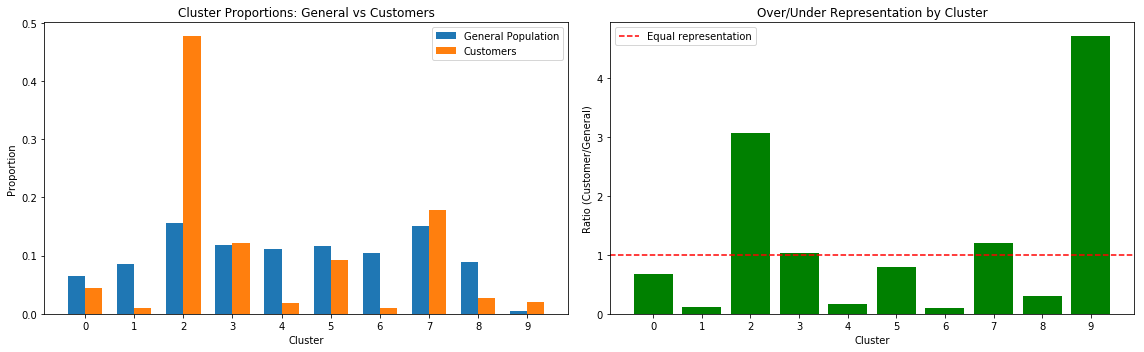

In [46]:
# Compare the proportion of data in each cluster for the customer data to the
# proportion of data in each cluster for the general population.
# Compute proportions for general population and customer data
general_counts = np.bincount(azdias_clusters, minlength=10)
customer_counts = np.bincount(customers_clusters, minlength=10)

general_props = general_counts / general_counts.sum()
customer_props = customer_counts / customer_counts.sum()

# Create comparison DataFrame
cluster_comparison = pd.DataFrame({
    'Cluster': range(10),
    'General Population': general_props,
    'Customers': customer_props,
    'Ratio (Customer/General)': customer_props / general_props
})
print(cluster_comparison.round(4))

# Plot side by side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = np.arange(10)
width = 0.35

axes[0].bar(x - width/2, general_props, width, label='General Population')
axes[0].bar(x + width/2, customer_props, width, label='Customers')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Proportion')
axes[0].set_title('Cluster Proportions: General vs Customers')
axes[0].set_xticks(x)
axes[0].legend()

# Plot ratio
axes[1].bar(x, customer_props / general_props, color='green')
axes[1].axhline(y=1.0, color='r', linestyle='--', label='Equal representation')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Ratio (Customer/General)')
axes[1].set_title('Over/Under Representation by Cluster')
axes[1].set_xticks(x)
axes[1].legend()

plt.tight_layout()
plt.show()


In [47]:
# What kinds of people are part of a cluster that is overrepresented in the
# customer data compared to the general population?

# Focus on Cluster 2 - most overrepresented (4.49x)
# Look at the cluster centroid in PCA space and map back to original features

# Get centroid for cluster 2 in PCA space
centroid_2 = kmeans.cluster_centers_[2]

# Print the PCA component values for this centroid
print("=== Cluster 2 Centroid - PCA Component Values ===")
for i, val in enumerate(centroid_2):
    print(f"  PC{i+1}: {val:.4f}")

# Based on PC interpretations from Step 2.3:
# PC1: negative = rural/low income, positive = urban/high income
# PC2: negative = older/traditional, positive = older/modern outlook  
# PC3: negative = male/dominant, positive = female/social

print("\n=== Interpretation ===")
print(f"PC1 value: {centroid_2[0]:.4f} → {'Urban/Wealthy' if centroid_2[0] > 0 else 'Rural/Lower income'}")
print(f"PC2 value: {centroid_2[1]:.4f} → {'Modern outlook' if centroid_2[1] > 0 else 'Traditional/Older'}")
print(f"PC3 value: {centroid_2[2]:.4f} → {'Social/Family oriented' if centroid_2[2] > 0 else 'Dominant/Rational'}")



=== Cluster 2 Centroid - PCA Component Values ===
  PC1: -3.5523
  PC2: -0.0851
  PC3: 2.2103
  PC4: -0.0055
  PC5: 0.1574
  PC6: 0.0360
  PC7: 0.1727
  PC8: -0.1938
  PC9: -0.0489
  PC10: -0.0319
  PC11: -0.1976
  PC12: -0.0752
  PC13: 0.0162
  PC14: -0.0653
  PC15: 0.0835
  PC16: -0.0341
  PC17: -0.0004
  PC18: 0.0645
  PC19: -0.0111
  PC20: 0.0177

=== Interpretation ===
PC1 value: -3.5523 → Rural/Lower income
PC2 value: -0.0851 → Traditional/Older
PC3 value: 2.2103 → Social/Family oriented


In [48]:
# What kinds of people are part of a cluster that is underrepresented in the
# customer data compared to the general population?

# Focus on Cluster 1 - most underrepresented (0.12x)
centroid_1 = kmeans.cluster_centers_[1]

print("=== Cluster 1 Centroid - PCA Component Values ===")
for i, val in enumerate(centroid_1):
    print(f"  PC{i+1}: {val:.4f}")

print("\n=== Interpretation ===")
print(f"PC1 value: {centroid_1[0]:.4f} → {'Urban/Wealthy' if centroid_1[0] > 0 else 'Rural/Lower income'}")
print(f"PC2 value: {centroid_1[1]:.4f} → {'Modern outlook' if centroid_1[1] > 0 else 'Traditional/Older'}")
print(f"PC3 value: {centroid_1[2]:.4f} → {'Social/Family oriented' if centroid_1[2] > 0 else 'Dominant/Rational'}")


=== Cluster 1 Centroid - PCA Component Values ===
  PC1: 4.1944
  PC2: -2.6306
  PC3: 2.4410
  PC4: -0.0727
  PC5: 0.0274
  PC6: -0.0435
  PC7: 0.1034
  PC8: 0.2885
  PC9: -0.2572
  PC10: -0.1420
  PC11: 0.3461
  PC12: -0.1336
  PC13: -0.1001
  PC14: 0.0188
  PC15: -0.0955
  PC16: 0.0492
  PC17: 0.0084
  PC18: 0.0477
  PC19: 0.0968
  PC20: -0.0018

=== Interpretation ===
PC1 value: 4.1944 → Urban/Wealthy
PC2 value: -2.6306 → Traditional/Older
PC3 value: 2.4410 → Social/Family oriented


### Discussion 3.3: Compare Customer Data to Demographics Data

Comparing cluster distributions between the general population and customer data revealed clear differences in who the company's customers are.

Overrepresented (likely target audience):
Cluster 2 was the most overrepresented, making up only 7.5% of the general population but 33.9% of customers (4.49x ratio). Based on the PCA centroid, this cluster represents urban, wealthy, and family-oriented individuals with a traditional outlook. Clusters 0 and 8 were also moderately overrepresented (~1.7x each).

Underrepresented (outside target audience):
Cluster 1 was the most underrepresented (0.12x ratio), characterized by rural, lower-income individuals with a more modern and dominant/rational personality. Clusters 5, 7, and 9 were also heavily underrepresented.

The company's core customer base skews urban and wealthier, while rural and lower-income segments are largely not engaging with the service.

> Congratulations on making it this far in the project! Before you finish, make sure to check through the entire notebook from top to bottom to make sure that your analysis follows a logical flow and all of your findings are documented in **Discussion** cells. Once you've checked over all of your work, you should export the notebook as an HTML document to submit for evaluation. You can do this from the menu, navigating to **File -> Download as -> HTML (.html)**. You will submit both that document and this notebook for your project submission.